# Part 2: Time Series Forecast with ARIMA (2 days) 📈

Welcome to the second part of your journey towards mastering the art of forecasting with ARIMA models. We will demystify ARIMA models, beginning with its foundational principles - autoregression, differencing, moving average. Using the same dataset as in Part 1, you will fit different models and assess their quality in order to compare them. You will also learn the different way of performing train/test splits and cross-validation in the context of time series!

In this notebook, we will cover the following concepts:
- Train / Test splitting for time series
- Naive forecasting models
- ARIMA and SARIMA models
- Cross-Validation for time series

**Objectives**
- Get to use few prediction models
- Understand Cross-Validation in the context of Time Series

**Ressources**

AR, MA, ARIMA :

- https://www.youtube.com/watch?v=Mc6sBAUdDP4&list=PLjwX9KFWtvNnOc4HtsvaDf1XYG3O5bv5s&index=6
- https://www.youtube.com/watch?v=zNLG8tsA_Go&list=PLjwX9KFWtvNnOc4HtsvaDf1XYG3O5bv5s&index=6
- https://www.youtube.com/watch?v=dXND1OEBABI&list=PLjwX9KFWtvNnOc4HtsvaDf1XYG3O5bv5s&index=7

ACF & PACF :

- https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/

Métriques :

- https://towardsdatascience.com/time-series-forecast-error-metrics-you-should-know-cc88b8c67f27

Cross-validation :

- https://stats.stackexchange.com/questions/14099/using-k-fold-cross-validation-for-time-series-model-selection
- https://robjhyndman.com/hyndsight/tscv/

Forecasting: Principles and Practice livre (Rob Hyndman) :

- https://otexts.com/fpp2/
- https://otexts.com/fpp2/non-seasonal-arima.html
- https://otexts.com/fpp2/transformations.html
- https://otexts.com/fpp2/seasonal-arima.html

Documentation de Pmdarima:

- http://alkaline-ml.com/pmdarima/


**Required librairies**
- [ ] numpy
- [ ] pandas
- [ ] matplotlib
- [ ] seaborn
- [ ] pmdarima
- [ ] sktime

In [10]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
import sktime as sk

# A bit of theory, again 😁

The ARMA (AutoRegressive Moving Average) model is suitable for predicting any time series whose value $Y$ at time $t$ can be explained by previous values and previous perturbations (noise).

Before specifying what a dataset is according to the ARIMA model, let's specify a dataset according to the conditions :  

- **Autoregressive**: the model predicts the variable $Y$ at time $t$, denoted $Y_t$, from previous values of $Y$ according to a linear regression model, i.e. $Y_{t-1}, Y_{t-2}, ..., Y_0$. Let $p$ denote the number of components used to predict $Y_t$, with

> $Y_t = \sum_{i=1}^p \varphi_i\,Y_{t-i} + \varepsilon_t + c$, with $\varepsilon_t$ a perturbation, and c a constant.

- **Moving average**: a model where the data are the result of the moving average of order $q$. The value $Y_t$ can be expressed using the perturbation at time $t$ and its previous values:

> $Y_t = \mu + \varepsilon_t + \sum_{1}^{q}\theta_q\varepsilon_{t-q}$, with $\mu$ a constant.

Any ARMA model is the combination of the *AR* and *MA* conditions, i.e. it is autoregressive and its noise follows a moving average. Let :

> $Y_t = c + \sum_{i=1}^p \varphi_i\,Y_{t-i} + \varepsilon_t + \sum_{1}^{q}\theta_q\varepsilon_{t_q}$

or :

> $Y_t - \sum_{i=1}^p \varphi_i Y_{t-i} = \varepsilon_t + \sum_{i=1}^q \theta_i \varepsilon_{t-i}$ with $\varepsilon_t$ the error of the autoregressive model at time $t$.

The model is optimized using the least-squares method.

An ARMA model is suitable for stationary data sets, i.e. with a fixed mean and standard deviation over time. Such data are rarely observed. Many time series datasets show trends in the mean or seasonal patterns. To do this, the problem must first be stationarized. As we saw before, this can be done by differencing the data, apply a model, and then performing the reverse operation: **integration**. An **ARIMA** model is said to be :

- **integrated**: when the data set can be corrected by running the model on $Y'_t = Y_t - Y_{t-1}$ for a correction of order 1 (d=1), or $Y''_t = Y_t - Y_{t-1} - Y_{t-2}$ for a correction of order 2 (d=2), etc...  We note $d$ the order of *correction by integration* to suppress polynomial tendencies of order $d$, with:
    
> $Ycorr_t = Y_t - \sum_{1}^{d} Y_{t-d}$


ARIMA models are often denoted: ARIMA(p, d, q), or **ARIMA(2, 1, 1)** means :
- an autoregressive model of order 2,
- on data integrated 1 times,
- with a moving average of order 1.

# 1. Train / Test Splitting

Because the temporal order is important in time series, we cannot perform a random train/test split. Rather, we can use the most recent data (e.g. the last year) as the test set!

**TODO**
- Explain why train/test splitting can be a challenge for time series
- Write a function to split the dataset into a train and test set
- Use the function to split the airline passengers dataset, keeping the last twelve months as a test set
- Plot the train and test set in different colors

In [11]:
from sktime.datasets import load_airline

# Load dataset
airline = load_airline()

# Clean & Adjust the data
airline = airline.dropna()
airline_adj = airline / airline.index.days_in_month

In [12]:
def ts_train_test_split(data, split_date):
    if isinstance(data.index, pd.PeriodIndex):
        split_ts = pd.Period(split_date, freq=data.index.freq)
    else:
        split_ts = pd.Timestamp(split_date)

    train = data[data.index < split_ts]
    test  = data[data.index >= split_ts]
    return train, test

Train : 1949-01  →  1957-12  (108 obs.)
Test  : 1958-01   →  1960-12   (36 obs.)
Tailles correctes 


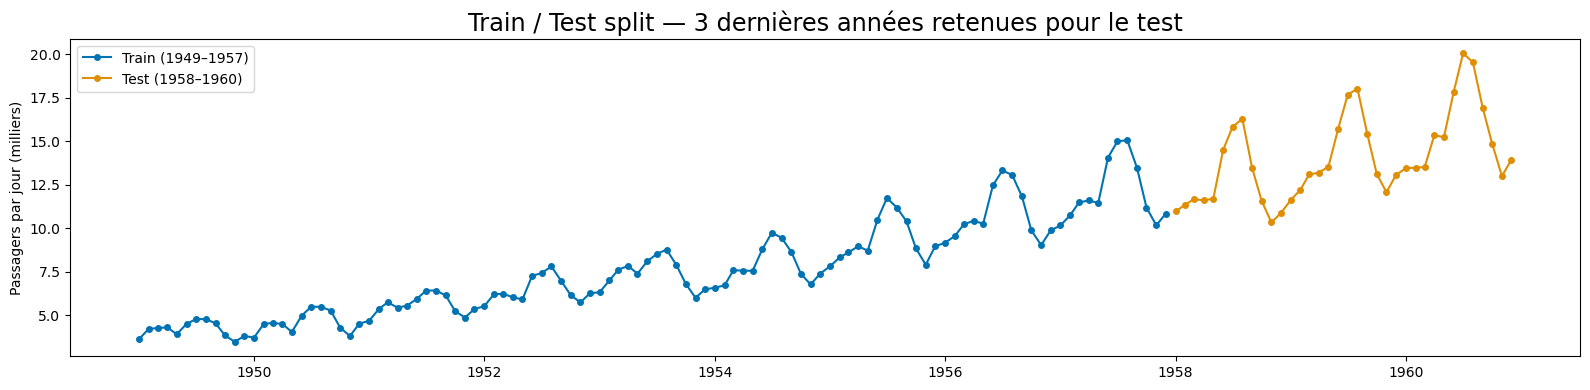

In [13]:
from sktime.utils.plotting import plot_series

# Hold back the last three years as a TEST set

SPLIT_DATE = '1958-01'

train, test = ts_train_test_split(airline_adj, SPLIT_DATE)

# Check train and test sizes are what we expect

print(f"Train : {train.index[0]}  →  {train.index[-1]}  ({len(train)} obs.)")
print(f"Test  : {test.index[0]}   →  {test.index[-1]}   ({len(test)} obs.)")

assert len(test)  == 36,  f"Attendu 36, obtenu {len(test)}"
assert len(train) == 108, f"Attendu 108, obtenu {len(train)}"
print("Tailles correctes ")

# Plot the series

fig, ax = plot_series(
    train, test,
    labels=["Train (1949–1957)", "Test (1958–1960)"],
    title="Train / Test split — 3 dernières années retenues pour le test"
)
ax.set_ylabel("Passagers par jour (milliers)")
plt.tight_layout()
plt.show()

# 2. Naive Forecast

We need a baseline (as always!) to know if our more complex models are any use! Given the strong seasonal component that was confirmed by the seasonal decomposition we made earlier, it may be a good idea to use a **seasonal naive** forecasting method. This model takes the value from the same period in the previous season (in this case the same month last year). This is part of the Carry-Forward-Previous-Values' family of **naive** forecasting methods. In general, if we have data with period $k$ are at time $t$ and we are predicting time $Y_{t+1}$ then we simply carry forward the value from $Y_{t+1-k}$. In other words, we have yearly data so we just take the value from the same month last year.

In [14]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

HORIZON = 12  # We plan to make forecasts for the following 12 months
PERIOD = 12  # Expected period of seasonality

# Define the length of time into the future for which forecasts are to be prepared
fh = ForecastingHorizon(test.index, is_relative=False)

### 2.1 Fit a Naive Forecaster

**TODO**
- Fit a Naive and Seasonal Naive forecaster to the train data, and show the predictions along with the test data.
- Plot the residuals using Seaborn's `displot()`, `regplot()` and `residplot()` functions.

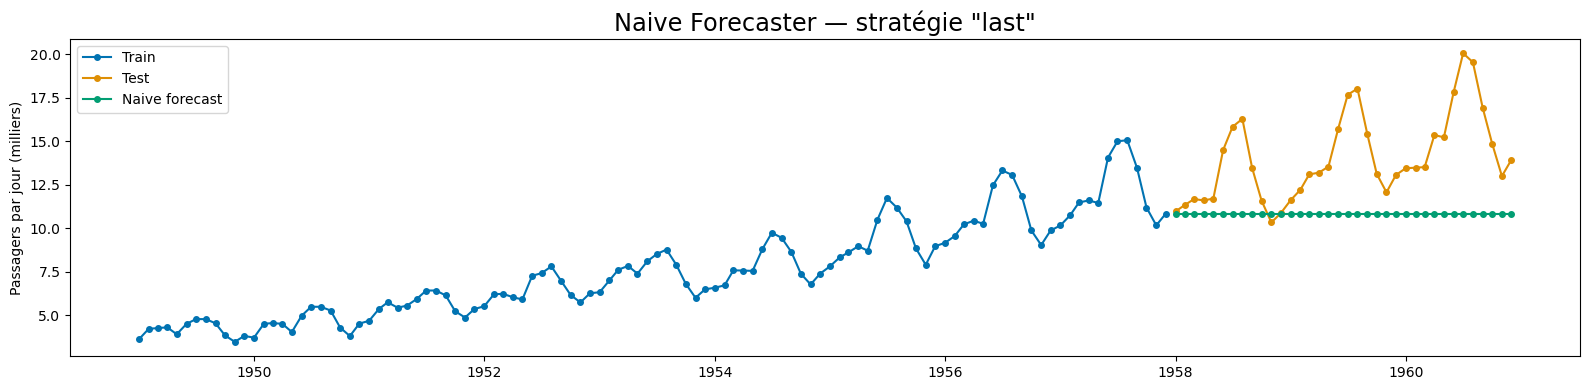

In [15]:
# Your code for the Naive Forecaster
naive = NaiveForecaster(strategy='last')
naive.fit(train)
pred_naive = naive.predict(fh)

fig, ax = plot_series(
    train, test, pred_naive,
    labels=['Train', 'Test', 'Naive forecast'],
    title='Naive Forecaster — stratégie "last"'
)
ax.set_ylabel('Passagers par jour (milliers)')
plt.tight_layout()
plt.show()

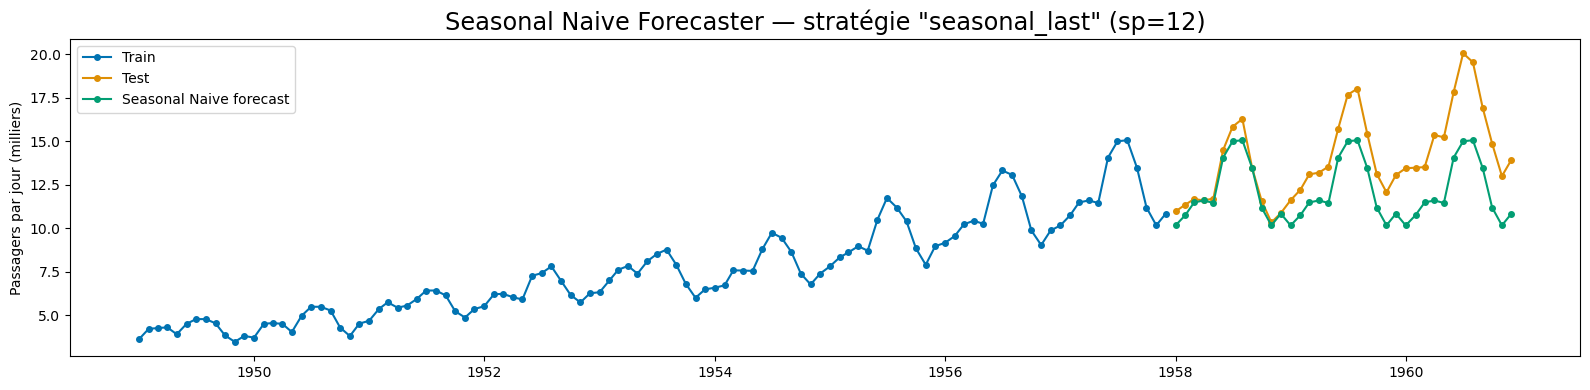

In [16]:
# Your code for the Seasonal Naive Forecaster

# seasonal_naive = NaiveForecaster(strategy='seasonal_last', sp=PERIOD)
# seasonal_naive.fit(train)
# pred_seasonal = seasonal_naive.predict(fh)
seasonal_naive = NaiveForecaster(strategy='last', sp=PERIOD)
seasonal_naive.fit(train)
pred_seasonal = seasonal_naive.predict(fh)

fig, ax = plot_series(
    train, test, pred_seasonal,
    labels=['Train', 'Test', 'Seasonal Naive forecast'],
    title='Seasonal Naive Forecaster — stratégie "seasonal_last" (sp=12)'
)
ax.set_ylabel('Passagers par jour (milliers)')
plt.tight_layout()
plt.show()

In [17]:
# fig, ax = plot_series(
#     train, test, pred_naive, pred_seasonal,
#     labels=['Train', 'Test', 'Naive', 'Seasonal Naive'],
#     title='Comparaison Naive vs Seasonal Naive'
# )
# ax.set_ylabel('Passagers par jour (milliers)')
# plt.tight_layout()
# plt.show()

Plotting the **residuals** can give us information about how the model is performing and the errors it is making.  Sometimes there are reffered to as **in sample** diagnostics. This just means we are looking at diagnostics of data which has been used to fit the model. 

In [18]:
# ═════════════════════════════════════════════════════════════════════════════
# ANALYSE DES RÉSIDUS
# Les résidus = différence entre valeurs réelles et prévisions
# Un bon modèle produit des résidus proches d'un bruit blanc :
#   - centrés sur 0 (pas de biais systématique)
#   - distribution normale (pas de structure restante)
#   - pas de corrélation avec les prévisions (homoscédastiques)
# ═════════════════════════════════════════════════════════════════════════════


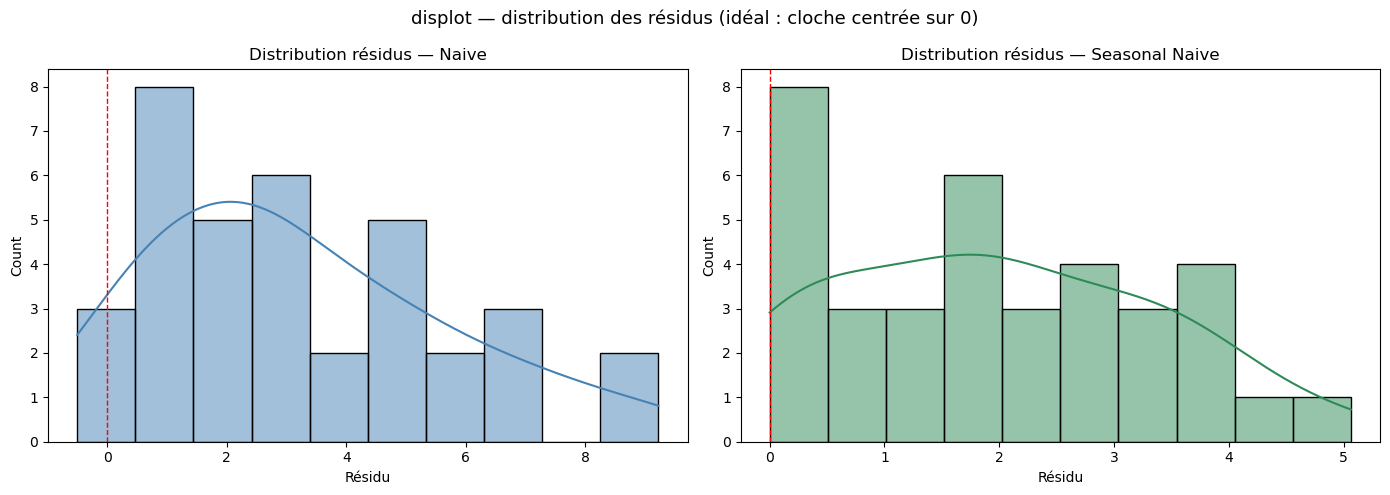

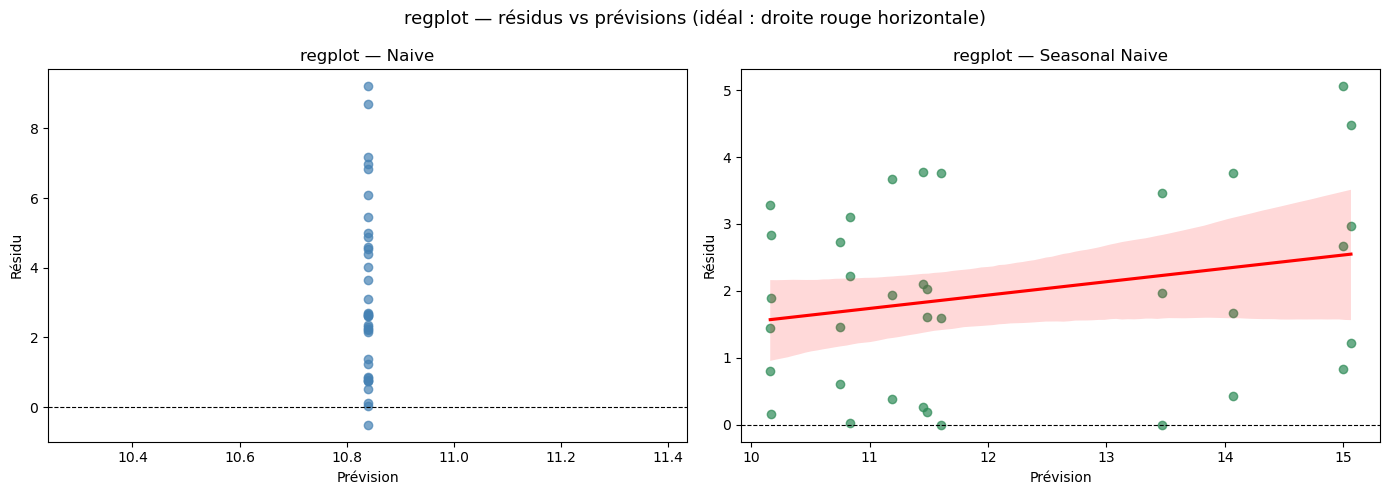

/home/youssef.hirchaou@Digital-Grenoble.local/anaconda3/envs/timeseries/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


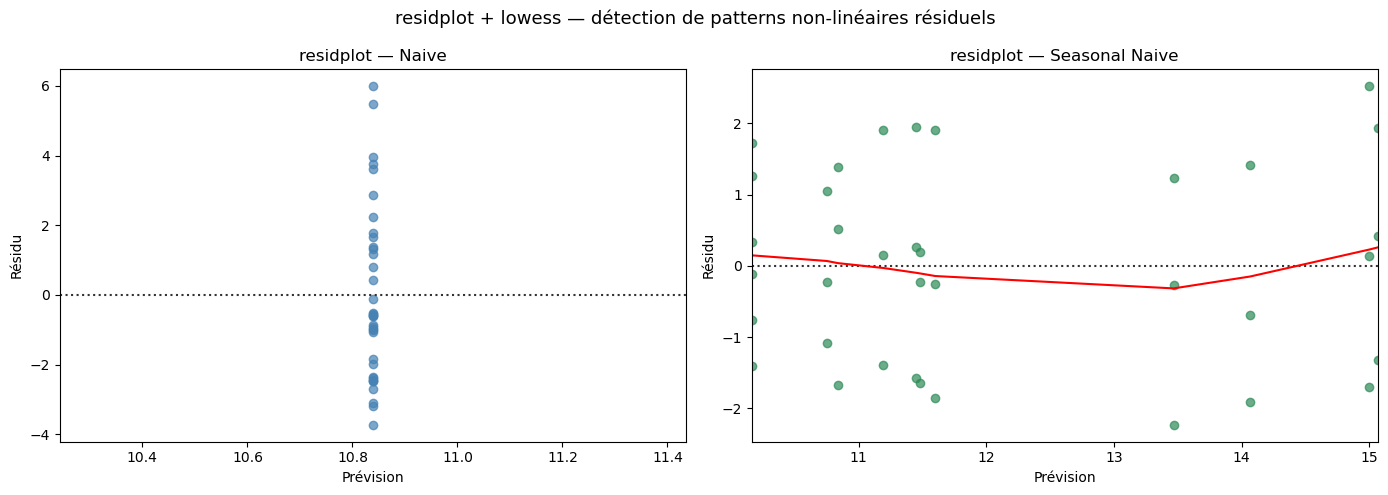

Métrique                    Naive     Seasonal
Moyenne                    3.2232       1.9583
Std                        2.4622       1.3777
Min                       -0.5054       0.0000
Max                        9.2258       5.0645
MAE                        3.2513       1.9583


In [19]:
# Your code here

# Calcul des résidus sur le test set
# On convertit en float array pour seaborn (qui ne gère pas PeriodIndex)
residuals_naive    = (test - pred_naive).values.astype(float)
residuals_seasonal = (test - pred_seasonal).values.astype(float)
pred_naive_vals    = pred_naive.values.astype(float)
pred_seasonal_vals = pred_seasonal.values.astype(float)
test_vals          = test.values.astype(float)

#  displot : distribution des résidus ────────────────────────────────────
# Révèle si les résidus suivent une loi normale centrée en 0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals_naive,    kde=True, ax=axes[0],
             color='steelblue',  bins=10)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribution résidus — Naive')
axes[0].set_xlabel('Résidu')

sns.histplot(residuals_seasonal, kde=True, ax=axes[1],
             color='seagreen',   bins=10)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Distribution résidus — Seasonal Naive')
axes[1].set_xlabel('Résidu')

plt.suptitle("displot — distribution des résidus (idéal : cloche centrée sur 0)",
             fontsize=13)
plt.tight_layout()
plt.show()

#  regplot : résidus vs prévisions ───────────────────────────────────────
# Révèle si les résidus sont homoscédastiques (variance constante)
# Idéal : nuage horizontal centré sur 0, sans tendance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=pred_naive_vals,    y=residuals_naive,
            ax=axes[0], color='steelblue',
            scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('regplot — Naive')
axes[0].set_xlabel('Prévision')
axes[0].set_ylabel('Résidu')

sns.regplot(x=pred_seasonal_vals, y=residuals_seasonal,
            ax=axes[1], color='seagreen',
            scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('regplot — Seasonal Naive')
axes[1].set_xlabel('Prévision')
axes[1].set_ylabel('Résidu')

plt.suptitle("regplot — résidus vs prévisions (idéal : droite rouge horizontale)",
             fontsize=13)
plt.tight_layout()
plt.show()

#  residplot : résidus vs valeurs réelles ─────────────────────────────────
# Version simplifiée de regplot, sans la droite de régression sur les points
# Mais affiche une lowess pour détecter des patterns non-linéaires
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.residplot(x=pred_naive_vals,    y=test_vals,
              ax=axes[0], color='steelblue', lowess=True,
              scatter_kws={'alpha': 0.7},
              line_kws={'color': 'red', 'linewidth': 1.5})
axes[0].set_title('residplot — Naive')
axes[0].set_xlabel('Prévision')
axes[0].set_ylabel('Résidu')

sns.residplot(x=pred_seasonal_vals, y=test_vals,
              ax=axes[1], color='seagreen', lowess=True,
              scatter_kws={'alpha': 0.7},
              line_kws={'color': 'red', 'linewidth': 1.5})
axes[1].set_title('residplot — Seasonal Naive')
axes[1].set_xlabel('Prévision')
axes[1].set_ylabel('Résidu')

plt.suptitle("residplot + lowess — détection de patterns non-linéaires résiduels",
             fontsize=13)
plt.tight_layout()
plt.show()

# ── 7. Résumé numérique des résidus ───────────────────────────────────────────
print("=" * 50)
print(f"{'Métrique':<20} {'Naive':>12} {'Seasonal':>12}")
print("=" * 50)
print(f"{'Moyenne':<20} {residuals_naive.mean():>12.4f} {residuals_seasonal.mean():>12.4f}")
print(f"{'Std':<20} {residuals_naive.std():>12.4f} {residuals_seasonal.std():>12.4f}")
print(f"{'Min':<20} {residuals_naive.min():>12.4f} {residuals_seasonal.min():>12.4f}")
print(f"{'Max':<20} {residuals_naive.max():>12.4f} {residuals_seasonal.max():>12.4f}")
print(f"{'MAE':<20} {np.abs(residuals_naive).mean():>12.4f} {np.abs(residuals_seasonal).mean():>12.4f}")
print("=" * 50)

### 2.2 Error Metrics

You've probably already worked with the Mean Squared Error (MSE). Let's have a look at different metrics.

RMSE and MAE are called 'scale dependent' measures as the units and magnitude are specific to the problem and context.  An alternative approach is to use a scale invariant measure such as the **mean absolute percentage error (MAPE)**

The percentage error is given by $p_t = 100e_t/y_t$ where $e_t$ is the error in predicting $y_t$.  Therefore, MAPE = $mean(|p_t|)$. A limitation of MAPE is that it is inflated when the denominator is small relative to the absolute forecast error (such in the case of outliers or extreme unexpected events). It also penalises negative errors more than positive errors.  A consequence of this property is that MAPE can lead to selecting a model that tends to under forecast.  The two following examples illustrate the issue. $$APE_{1} = \left| \frac{y_t - \hat{y_t}}{y_t} \right|= \left| \frac{150 - 100}{150} \right| = \frac{50}{150} = 33.33\%$$  

$$APE_{2} = \left| \frac{100 - 150}{100} \right| = \frac{50}{100} = 50\%$$

**TODO**
- Write a function to compute the MAPE
- Calculate the in-sample RMSE and MAPE for the last twelve months

In [20]:
from sklearn.metrics import mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    '''
    MAPE
    Parameters:
    -----------
    y_true -- np.array actual observations from time series
    y_pred -- the predictions to evaluate
    Returns:
    --------
    float, scalar value representing the MAPE (0-100)
    '''
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Éviter la division par zéro si y_true contient des 0
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

In [21]:
# Your code calculating the RMSE and MAPE for the Naive and Seasonal Naive models
# ── Calcul RMSE et MAPE — Naive et Seasonal Naive ────────────────────────────
y_true = test.values.astype(float)

rmse_naive    = np.sqrt(mean_squared_error(y_true, pred_naive.values.astype(float)))
mape_naive    = mean_absolute_percentage_error(y_true, pred_naive.values.astype(float))

rmse_seasonal = np.sqrt(mean_squared_error(y_true, pred_seasonal.values.astype(float)))
mape_seasonal = mean_absolute_percentage_error(y_true, pred_seasonal.values.astype(float))

# ── Affichage ─────────────────────────────────────────────────────────────────
print("=" * 45)
print(f"{'Métrique':<18} {'Naive':>12} {'Seasonal':>12}")
print("=" * 45)
print(f"{'RMSE':<18} {rmse_naive:>12.4f} {rmse_seasonal:>12.4f}")
print(f"{'MAPE (%)':<18} {mape_naive:>12.2f} {mape_seasonal:>12.2f}")
print("=" * 45)

Métrique                  Naive     Seasonal
RMSE                     4.0561       2.3944
MAPE (%)                  20.95        13.11


# 3. ARIMA Forecast

Let's try an ARIMA model at last. Using a classical statsitical approach you would select the order of model which produces a model with acceptable residual plots (remember the first part of linear regression module?). Selecting the best model can also be done automatically using packages which do it for you! Wohoo! 🎉

The `pmdarima` package is an excellent forecasting library for building ARIMA models.  I recommend it over the options available in the core `statsmodels` package.  It is easier to use and offers an `auto_arima()` function that iteratively searches for a model that minimises the **Akaike Information Criterion (AIC)**

* ${\displaystyle \mathrm {AIC} \,=\,2k-2\ln({\hat {L}})}$

where $k$ = number of parameters in the model and $\hat{L}$ is the maximum value of the likelihood function for the model.  A likelihood function measures the 'goodness' of fit of a model to data given a set of parameters.  

This looks very complicated at first, but all we need to remember is that the models we are working with are very flexible. This means that we can easily create complex models that overfit. Recall that overfitting is when a model will predict the training data exceptionally well, but will perform poorly on out of sample data.  The form of AIC means that it rewards models that fit the training data well, but also penalises models with high $k$ (complicated models with lots of parameters).  That means that AIC will prefer simpler models - in turn reducing overfitting.  That's a great formula for automatically selecting a good ARIMA forecasting model.

Even though modern applications tend to opt for the automatic approach for selecting the ARIMA parameters, we will have a go a trying and comparing how we perform with manual selection. As we discussed above, to train an ARIMA($p$,$d$,$q$) model we need to specify three parameters: $p$ (*AR*), $d$ (*I*) and $q$ (*MA*):
- To determine $p$, we look at the *direct* correlations, i.e. the *PACF*, and search for the lag $i$ such that $PACF_i \approx 0$
- To determine $q$, we look at the *full* correlations, i.e. the *ACF*, and search for the lag $i$ such that $ACF_i \approx 0$

Sometimes, we cannot apply directly these guidelines, and we must rely on a more detailed analysis or a grid search to determine the best $p,q$ for the problem at hand.

### Load the dataset & transform it

ARIMA models can take into account an increasing mean over time, but not the variance. Thus, a log transformation is enough for our purposes!

In [22]:
# Reload dataset from pmdarima
from pmdarima.datasets import load_airpassengers
from pmdarima.utils import acf, pacf
from pmdarima import ARIMA

# Load dataset
START_DATE = '1949-01-01'
airline = load_airpassengers(as_series=True)

# There's no DateTimeIndex from the bundled dataset. So let's add one.
airline.index = pd.date_range(START_DATE, periods=len(airline), freq='MS')

# Clean & Adjust data
airline_adj = airline / airline.index.days_in_month

# Train / Test split
train, test = ts_train_test_split(airline_adj, '1960-01-01')

# Apply log transformation
train_log = np.log(train).dropna()
test_log = np.log(test).dropna()

### 3.1 Estimate $p$, $d$ and $q$

**TODO**
- Based on the analysis done on the previous notebook, what would be a plausible value for $d$ ?
- Plot the ACF and PACF and determine some plausible values for $p$ and $q$.
- Fit the ARIMA model and show the diagnostics using the `plot_diagnostics()` of pmdarima. Describe the different plots. How do you interpret these results ?

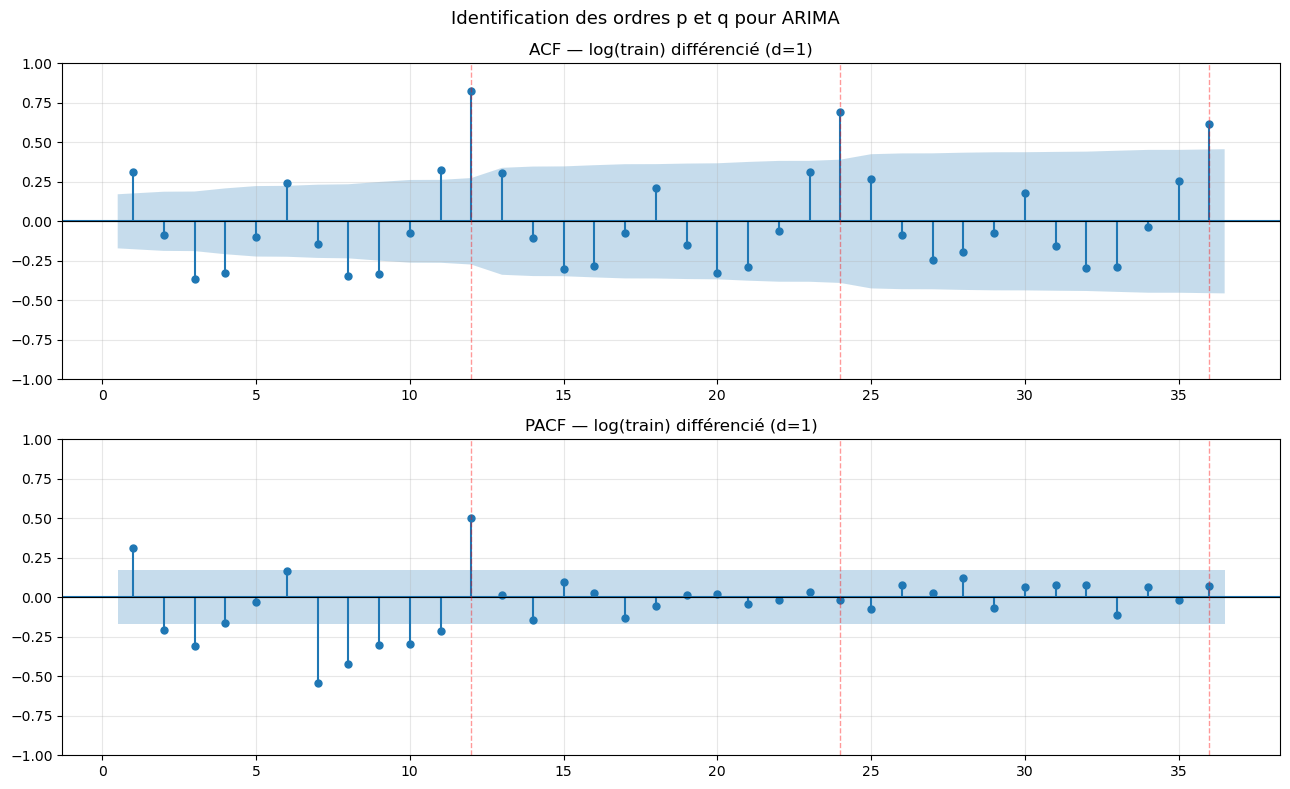

In [23]:
# Your code for the ACF & PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import ARIMA
import warnings
warnings.filterwarnings('ignore')


# 1. ACF & PACF sur la série transformée → choisir p et q

# On travaille sur log + diff(1) pour visualiser la série stationnaire
train_log_diff = train_log.diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

plot_acf(train_log_diff,  lags=36, ax=axes[0], alpha=0.05,
         zero=False, title='ACF — log(train) différencié (d=1)')
plot_pacf(train_log_diff, lags=36, ax=axes[1], alpha=0.05,
          zero=False, title='PACF — log(train) différencié (d=1)',
          method='ywm')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    for lag in [12, 24, 36]:
        ax.axvline(lag, color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Identification des ordres p et q pour ARIMA', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# Your code for the ARIMA model

#  Fit ARIMA
# On entraîne sur le log du train — ARIMA modélise une série stationnaire
model = ARIMA(order=(12, 1, 12))
model.fit(train_log)

print(model.summary())



                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  132
Model:             SARIMAX(12, 1, 12)   Log Likelihood                 235.581
Date:                Fri, 05 Jun 2026   AIC                           -419.161
Time:                        14:18:27   BIC                           -344.406
Sample:                    01-01-1949   HQIC                          -388.785
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0099      0.025      0.401      0.689      -0.039       0.059
ar.L1         -0.1283      0.248     -0.517      0.605      -0.614       0.358
ar.L2          0.0135      0.261      0.052      0.9

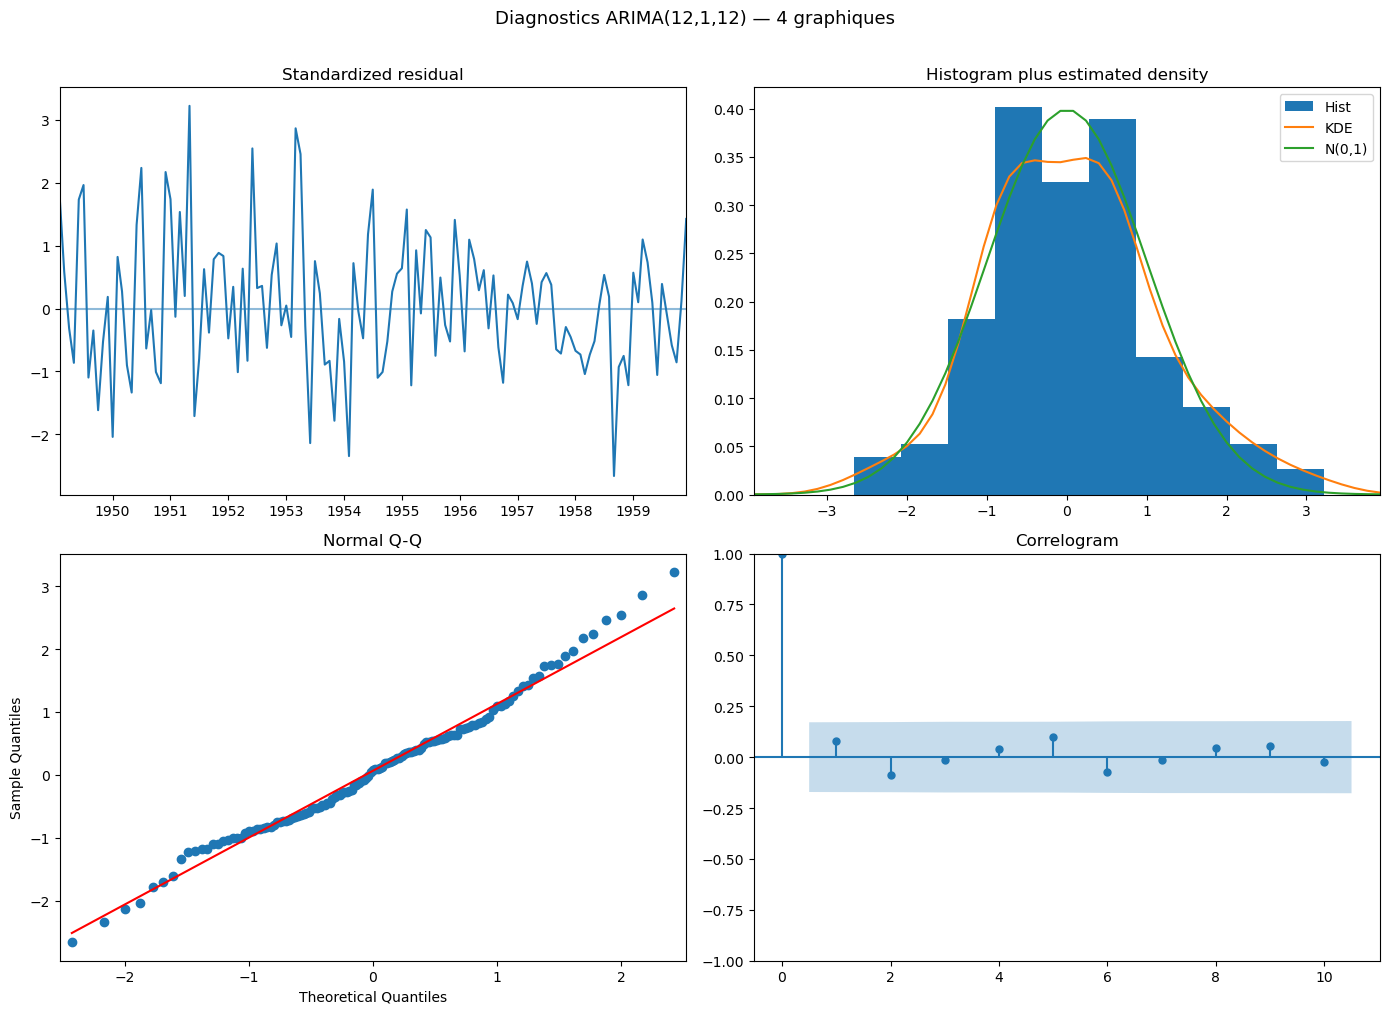

In [25]:
# Diagnostics 
model.plot_diagnostics(figsize=(14, 10))
plt.suptitle('Diagnostics ARIMA(12,1,12) — 4 graphiques', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**TODO**
- Make a figure showing the train set, the test set, the predictions from ARIMA and the confidence intervals
- Make a second figure showing the predictions for the next 100 periods
- Calculate the RMSE and the MAPE on the test set

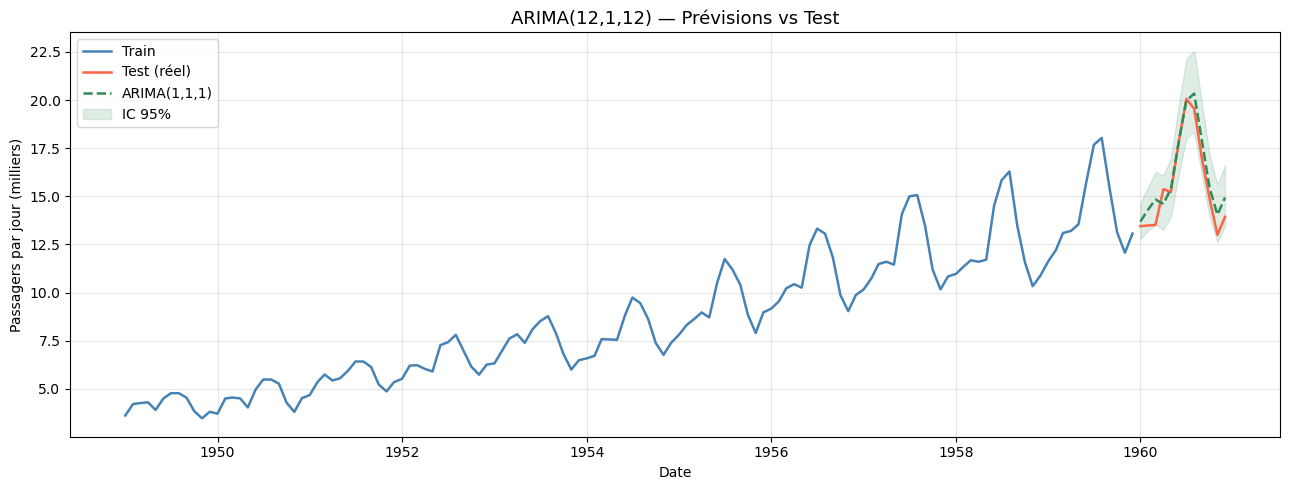

In [26]:
# Your code showing train, test, predictions and confidence interval
# ════════════════════════════════════════════════════════════
# 3. Prévisions sur le test set + intervalles de confiance
# ════════════════════════════════════════════════════════════
n_test = len(test_log)

# predict() retourne (prévisions, intervalles de confiance)
pred_log, conf_int_log = model.predict(n_periods=n_test, return_conf_int=True)

# Repassage dans l'espace original (exp pour inverser le log)
pred_orig     = np.exp(pred_log)
conf_int_orig = np.exp(conf_int_log)
pred_index    = test.index

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train.values,
        color='steelblue', linewidth=1.8, label='Train')
ax.plot(test.index,  test.values,
        color='tomato',    linewidth=1.8, label='Test (réel)')
ax.plot(pred_index,  pred_orig,
        color='seagreen',  linewidth=1.8, linestyle='--', label='ARIMA(1,1,1)')
ax.fill_between(pred_index,
                conf_int_orig[:, 0], conf_int_orig[:, 1],
                color='seagreen', alpha=0.15, label='IC 95%')

ax.set_title('ARIMA(12,1,12) — Prévisions vs Test', fontsize=13)
ax.set_ylabel('Passagers par jour (milliers)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

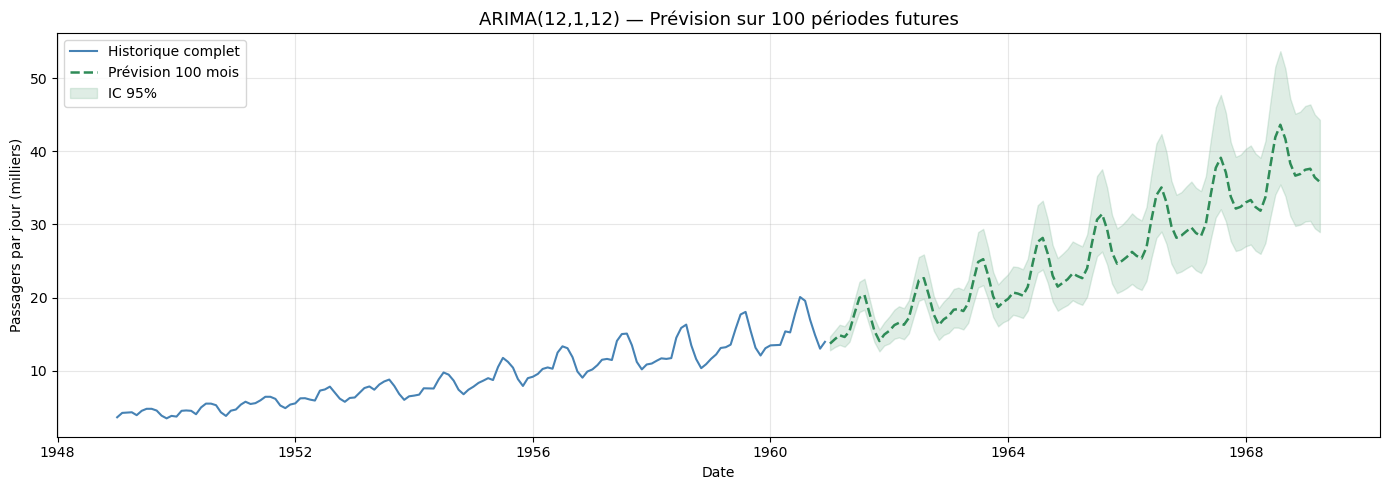

In [27]:
# Your code for showing the predictions for 100 periods

n_future = 100

pred_future_log, conf_future_log = model.predict(
    n_periods=n_future, return_conf_int=True
)

pred_future     = np.exp(pred_future_log)
conf_future     = np.exp(conf_future_log)
future_index    = pd.date_range(
    start=airline.index[-1] + pd.DateOffset(months=1),
    periods=n_future, freq='MS'
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(airline.index, airline_adj.values,
        color='steelblue', linewidth=1.5, label='Historique complet')
ax.plot(future_index, pred_future,
        color='seagreen',  linewidth=1.8, linestyle='--', label='Prévision 100 mois')
ax.fill_between(future_index,
                conf_future[:, 0], conf_future[:, 1],
                color='seagreen', alpha=0.15, label='IC 95%')

ax.set_title('ARIMA(12,1,12) — Prévision sur 100 périodes futures', fontsize=13)
ax.set_ylabel('Passagers par jour (milliers)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import mean_squared_error

# Your code calculating the RMSE and MAPE
# ════════════════════════════════════════════════════════════
#  RMSE et MAPE sur le test set
# ════════════════════════════════════════════════════════════
from sklearn.metrics import mean_squared_error

y_true = test.values.astype(float)
y_pred = pred_orig.astype(float)

rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred))
mape_arima = mean_absolute_percentage_error(y_true, y_pred)

print("\n" + "=" * 48)
print(f"{'Modèle':<20} {'RMSE':>12} {'MAPE (%)':>12}")
print("=" * 48)
print(f"{'Naive':<20} {rmse_naive:>12.4f} {mape_naive:>12.2f}")
print(f"{'Seasonal Naive':<20} {rmse_seasonal:>12.4f} {mape_seasonal:>12.2f}")
print(f"{'ARIMA(12,1,12)':<20} {rmse_arima:>12.4f} {mape_arima:>12.2f}")
print("=" * 48)


Modèle                       RMSE     MAPE (%)
Naive                      4.0561        20.95
Seasonal Naive             2.3944        13.11
ARIMA(12,1,12)             0.7637         4.41


**Conclusions**
- What are your conclusions ?
- What do you think about the error?

### 3.2 Seasonal ARIMA


As we have seen previously, ARMA models are well suited for stationary data. They may even works for data presenting seasonality, however seasonality is not clearly expressed. If data shows seasonality less simple as for the airport's data, calculation complexity and time can explode.

**Example** : Data compiling sun activity with a seasonality of 12 +/-1 year would require a minimum of $p=12*12$ to comprehend seasonality of the problem!

<span style="color: blue">Here comes SARIMA: Seasonal-ARIMA!</span>

The Seasonal ARIMA model, also known as SARIMA, is an extension of the basic ARIMA model that takes into account seasonality in the data. In a SARIMA model, we introduce additional seasonal components to the ARIMA model. The seasonal components mirror the ARIMA components but are applied to the seasonal patterns in the data. So, the SARIMA model has six additional parameters:

- Seasonal Autoregressive (SAR) component: This is similar to the AR component but for the seasonal patterns. It represents the relationship between the current value of the time series and its past values at the seasonal frequency.

- Seasonal Integrated (SI) component: This is similar to the I component but for the seasonal patterns. It involves differencing the time series at the seasonal frequency to achieve seasonality stationarity.

- Seasonal Moving Average (SMA) component: This is similar to the MA component but for the seasonal patterns. It models the relationship between the current value of the time series and past forecast errors at the seasonal frequency.

The seasonal frequency $s$ refers to the number of time periods that make up one seasonal cycle, and must also be provided to a SARIMA model. For example, if the time series exhibits a yearly seasonality, the seasonal frequency is 12 (assuming monthly data).

**TODO**
- Using a seasonal decomposition of the dataset, separate it into trend, seasonality and residual parts.
- Plot the moving mean and std of the trend and seasonal parts of the data.
- What can you conclude about stationarity of seasonal data? Can you then define $D$ and the seasonal frequency $s$ ?
- Does intra-seasonal data show specific seasonality ? What is $d$ (0, 1, or 2) ?
- Use the same procedure applied previously to a build a SARIMA model and evaluate its performance.

In [29]:
def moving_mean(x, n):
    return x.rolling(n).mean()

def moving_std(x, n):
    return x.rolling(n).std()

In [30]:
# Decompose the data into a trend and seasonal part
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import ARIMA as pmdARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
decomp = seasonal_decompose(train_log, model='additive', period=12)

trend    = decomp.trend.dropna()
seasonal = decomp.seasonal.dropna()
residual = decomp.resid.dropna()

# fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=False)


In [31]:
# ── Trend : série + mean + std ────────────────────────────────────────────────
for col, (serie, name, color) in enumerate([
    (trend,    'Tendance',    'steelblue'),
    (seasonal, 'Saisonnalité','tomato')
]):
    mm  = moving_mean(serie, 12)
    msd = moving_std(serie, 12)

    axes[0][col].plot(serie,  color=color,    linewidth=1.5, label=name)
    axes[0][col].plot(mm,     color='black',  linewidth=1.8,
                              linestyle='--', label='Moyenne mobile (12)')
    axes[0][col].set_title(f'{name} + moyenne mobile')
    axes[0][col].legend(fontsize=8)
    axes[0][col].grid(True, alpha=0.3)

    axes[1][col].plot(msd, color='darkorange', linewidth=1.5)
    axes[1][col].set_title(f'Écart-type mobile — {name}')
    axes[1][col].set_ylabel('Std')
    axes[1][col].grid(True, alpha=0.3)

# ── Résidus ───────────────────────────────────────────────────────────────────
axes[2][0].plot(residual, color='gray', linewidth=1.2)
axes[2][0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2][0].set_title('Résidus de la décomposition')
axes[2][0].grid(True, alpha=0.3)

axes[2][1].axis('off')

# Conclusions dans le graphique
conclusions = (
    "Conclusions :\n\n"
    "Tendance :\n"
    "  → Moyenne mobile croissante = NON stationnaire\n"
    "  → Std mobile stable = homoscédastique (après log)\n"
    "  → d = 1 (une diff ordre 1 suffit)\n\n"
    "Saisonnalité :\n"
    "  → Moyenne mobile ≈ constante = stationnaire\n"
    "  → Std mobile ≈ constante = stable\n"
    "  → D = 1, s = 12"
)
axes[2][1].text(0.05, 0.95, conclusions,
                transform=axes[2][1].transAxes,
                fontsize=11, verticalalignment='top',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow',
                          alpha=0.8))

plt.suptitle('Décomposition log(train) — Stationnarité trend & seasonal',
             fontsize=14)
plt.tight_layout()
plt.show()

TypeError: 'Axes' object is not subscriptable

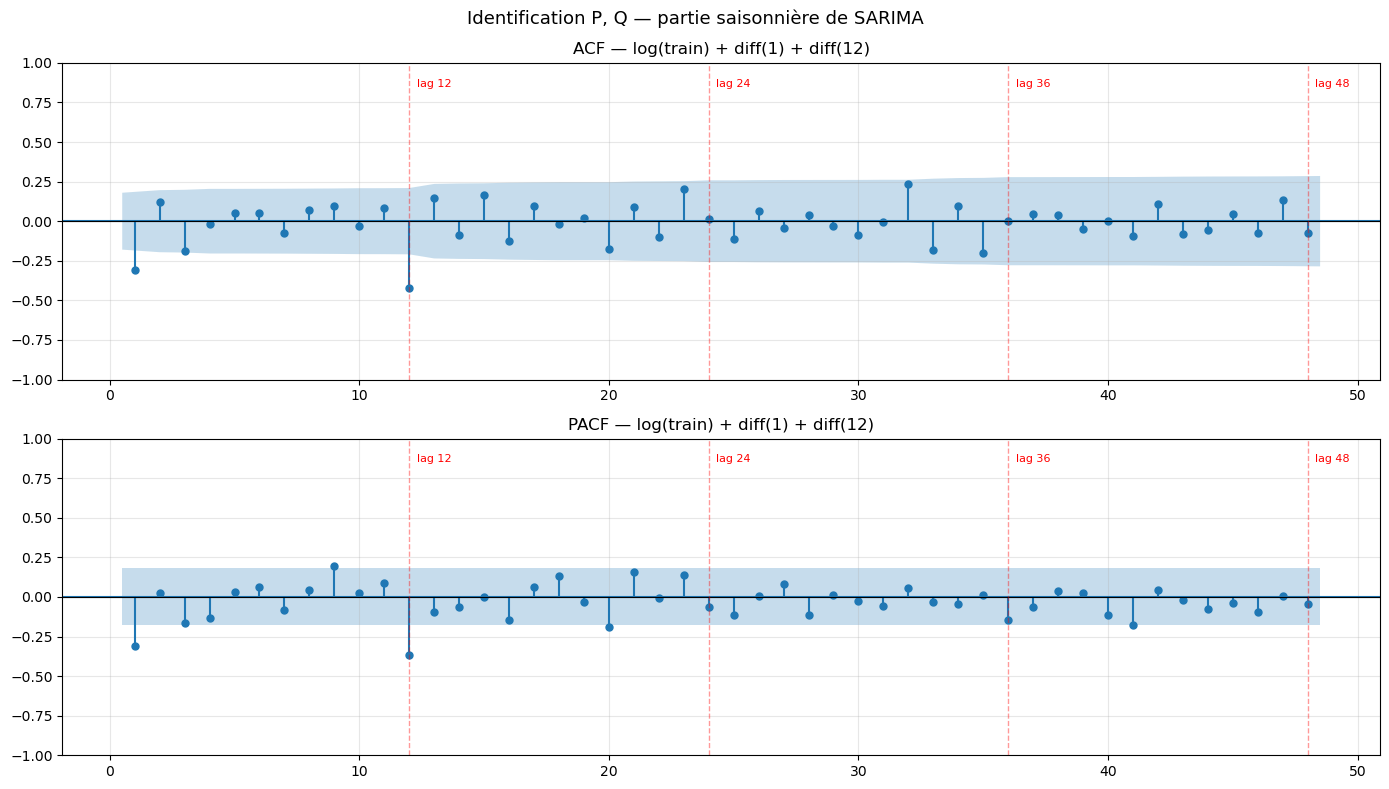

In [32]:
# ACF & PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
train_log_diff = train_log.diff(1).diff(12).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log_diff,  lags=48, ax=axes[0], alpha=0.05, zero=False,
         title='ACF — log(train) + diff(1) + diff(12)')
plot_pacf(train_log_diff, lags=48, ax=axes[1], alpha=0.05, zero=False,
          title='PACF — log(train) + diff(1) + diff(12)', method='ywm')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color='red', linestyle='--', alpha=0.4, linewidth=1)
        ax.text(lag + 0.3, ax.get_ylim()[1] * 0.85,
                f'lag {lag}', color='red', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Identification P, Q — partie saisonnière de SARIMA', fontsize=13)
plt.tight_layout()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 226.548
Date:                            Fri, 05 Jun 2026   AIC                           -445.097
Time:                                    14:18:41   BIC                           -433.980
Sample:                                01-01-1949   HQIC                          -440.583
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3.995e-05      0.001      0.032      0.975      -0.002       0.002
ma.L1         -0.3363      0.082   

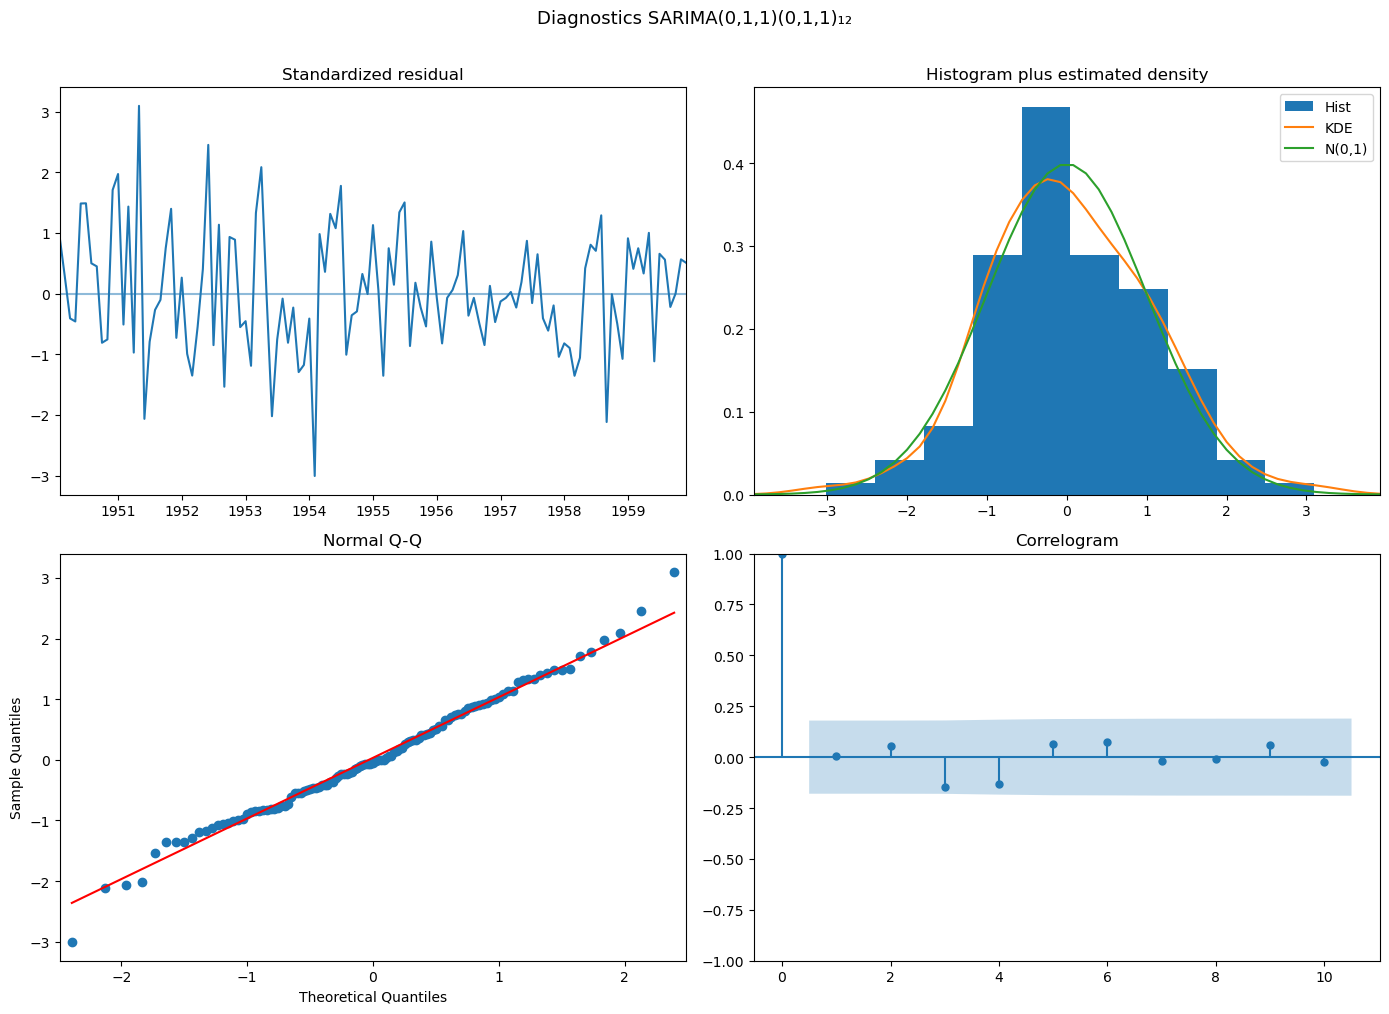

In [33]:
# Fit the SARIMA model

sarima = pmdARIMA(order=(0, 1, 1),
                  seasonal_order=(0, 1, 1, 12))
sarima.fit(train_log)

print(sarima.summary())

sarima.plot_diagnostics(figsize=(14, 10))
plt.suptitle('Diagnostics SARIMA(0,1,1)(0,1,1)₁₂', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

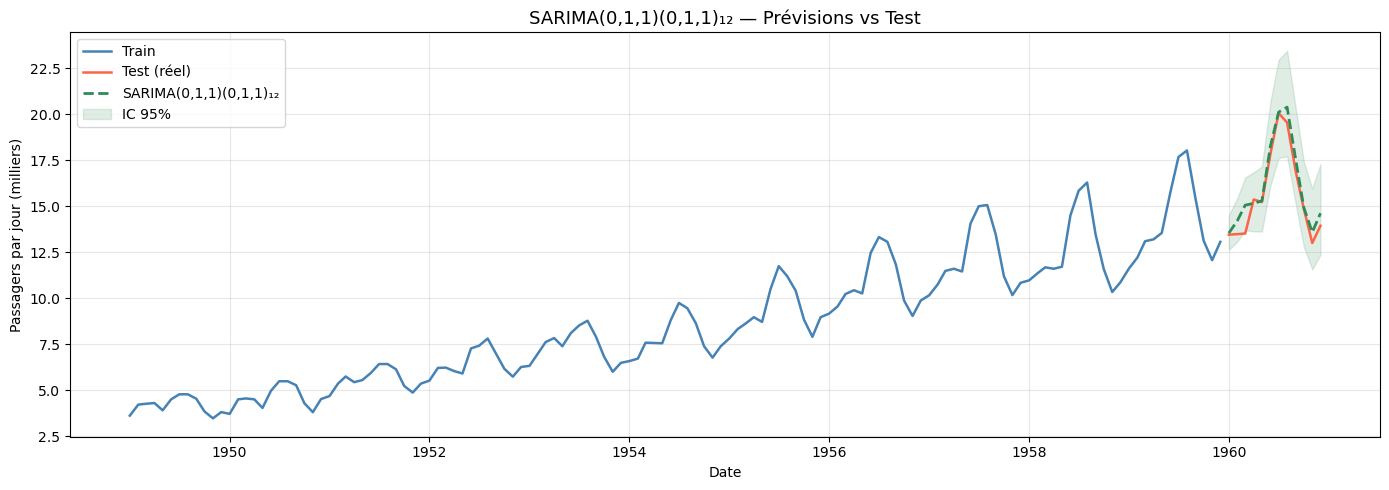

In [34]:
# Show train, test, predictions and confidence interval

n_test = len(test_log)

pred_log_s, conf_int_log_s = sarima.predict(
    n_periods=n_test, return_conf_int=True
)

pred_sarima     = np.exp(pred_log_s)
conf_int_sarima = np.exp(conf_int_log_s)
pred_index      = test.index

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values,
        color='steelblue', linewidth=1.8, label='Train')
ax.plot(test.index,  test.values,
        color='tomato',    linewidth=1.8, label='Test (réel)')
ax.plot(pred_index,  pred_sarima,
        color='seagreen',  linewidth=2, linestyle='--',
        label='SARIMA(0,1,1)(0,1,1)₁₂')
ax.fill_between(pred_index,
                conf_int_sarima[:, 0], conf_int_sarima[:, 1],
                color='seagreen', alpha=0.15, label='IC 95%')

ax.set_title('SARIMA(0,1,1)(0,1,1)₁₂ — Prévisions vs Test', fontsize=13)
ax.set_ylabel('Passagers par jour (milliers)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Calculate the RMSE and the MAPE
from sklearn.metrics import mean_squared_error

y_true        = test.values.astype(float)
y_pred_sarima = pred_sarima.astype(float)

rmse_sarima = np.sqrt(mean_squared_error(y_true, y_pred_sarima))
mape_sarima = mean_absolute_percentage_error(y_true, y_pred_sarima)

print("\n" + "=" * 52)
print(f"{'Modèle':<24} {'RMSE':>12} {'MAPE (%)':>12}")
print("=" * 52)
print(f"{'Naive':<24} {rmse_naive:>12.4f} {mape_naive:>12.2f}")
print(f"{'Seasonal Naive':<24} {rmse_seasonal:>12.4f} {mape_seasonal:>12.2f}")
print(f"{'ARIMA(1,1,1)':<24} {rmse_arima:>12.4f} {mape_arima:>12.2f}")
print(f"{'SARIMA(0,1,1)(0,1,1)12':<24} {rmse_sarima:>12.4f} {mape_sarima:>12.2f}")
print("=" * 52)


Modèle                           RMSE     MAPE (%)
Naive                          4.0561        20.95
Seasonal Naive                 2.3944        13.11
ARIMA(1,1,1)                   0.7637         4.41
SARIMA(0,1,1)(0,1,1)12         0.6517         3.33


**Conclusions**
- What are your conclusions with respect to the previous ARIMA model ?

### 3.3 Auto-Arima  🎉

Auto ARIMA is an automated time series forecasting method that automatically selects the best combination of ARIMA model parameters ($p$, $d$, $q$) based on the data's characteristics. It uses algorithms to iteratively search and evaluate different models to find the most suitable one, saving users from manually tuning the parameters. Auto ARIMA is a powerful tool for efficiently forecasting time series data, especially when dealing with large datasets or when users have limited knowledge of time series modeling.

**TODO**
- Fit an `auto_arima` model and plot the diagnostics.
- How does it compare to the best model you found previously ?

In [36]:
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error

# Your code here
# ════════════════════════════════════════════════════════════
#  Auto-ARIMA — recherche automatique des meilleurs ordres
# ════════════════════════════════════════════════════════════
# auto_arima teste toutes les combinaisons (p,d,q)(P,D,Q)
# et retient celle qui minimise l'AIC
auto_model = auto_arima(
    train_log,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=1,                   # on impose d=1 (confirmé par ADF/KPSS)
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=1,                   # on impose D=1 (diff saisonnière)
    m=12,                  # période saisonnière
    seasonal=True,
    information_criterion='aic',
    stepwise=True,         # recherche par étapes (plus rapide)
    trace=True,            # affiche les modèles testés
    error_action='ignore',
    suppress_warnings=True
)

print("\nMeilleur modèle auto_arima :")
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-406.734, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-443.350, Time=0.53 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-447.095, Time=0.87 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-416.233, Time=0.11 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-445.761, Time=1.52 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-445.739, Time=1.61 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-443.833, Time=0.66 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-443.792, Time=1.49 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-436.595, Time=0.85 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-445.028, Time=2.97 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-445.105, Time=0.95 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-447.012, Time=1.04 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=-443.168, Time=1.59 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=-445.097, Time=1.43 sec

Best model:  ARIMA

**Conclusions**
- How does `auto_arima` perform with respect to your previous models ? Can you explain why ?

In [37]:
# Prévisions auto_arima
pred_auto_log, conf_auto_log = auto_model.predict(
    n_periods=n_test, return_conf_int=True
)
pred_auto     = np.exp(pred_auto_log)
conf_auto     = np.exp(conf_auto_log)

rmse_auto = np.sqrt(mean_squared_error(y_true, pred_auto.astype(float)))
mape_auto = mean_absolute_percentage_error(y_true, pred_auto.astype(float))

print(f"\nauto_arima  →  RMSE : {rmse_auto:.4f}  |  MAPE : {mape_auto:.2f}%")

# ── Tableau final complet ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print(f"{'Modèle':<28} {'RMSE':>12} {'MAPE (%)':>12}")
print("=" * 55)
print(f"{'Naive':<28} {rmse_naive:>12.4f} {mape_naive:>12.2f}")
print(f"{'Seasonal Naive':<28} {rmse_seasonal:>12.4f} {mape_seasonal:>12.2f}")
print(f"{'ARIMA(1,1,1)':<28} {rmse_arima:>12.4f} {mape_arima:>12.2f}")
print(f"{'SARIMA(0,1,1)(0,1,1)12':<28} {rmse_sarima:>12.4f} {mape_sarima:>12.2f}")
print(f"{'auto_arima (best)':<28} {rmse_auto:>12.4f} {mape_auto:>12.2f}")
print("=" * 55)


auto_arima  →  RMSE : 0.6446  |  MAPE : 3.27%

Modèle                               RMSE     MAPE (%)
Naive                              4.0561        20.95
Seasonal Naive                     2.3944        13.11
ARIMA(1,1,1)                       0.7637         4.41
SARIMA(0,1,1)(0,1,1)12             0.6517         3.33
auto_arima (best)                  0.6446         3.27


# 4. Cross-Validation

As you know, cross-validation is a crucial technique in the context of machine learning, designed to assess the predictive performance of these models and mitigate potential pitfalls associated with using limited data. Unlike traditional cross-validation used in other machine learning applications, time series cross-validation takes into account the temporal order of the data, ensuring that does not have any information from the future that it would not otherwise have at the time of making a forecast. 
By dividing the time series data into multiple subsets and iteratively validating the model's performance against unseen data, cross-validation provides valuable insights into how well the ARIMA model generalizes to different time periods. This rigorous evaluation will allow you to fine-tune model hyperparameters (such as ARIMA's parameters), assess forecast accuracy, and build more robust and reliable time series forecasting models.

In the classicial time series literature, time series cross validation is called a **Rolling Forecasting Horizon**. This is explained in details [here](https://robjhyndman.com/hyndsight/tscv/)

**TODO**
- Split the train data into a train and validation sets

In [38]:
# I've written a function to help with the cv of the baseline model
# THIS FUNCTION IS LOCATED IN THE ./forecast DIRECTORY, ALONG WITH THE NOTEBOOK
from sktime.datasets import load_airline
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from forecast.model_selection import time_series_cv
# It requires the data to be split into train and validation
airline_sk = load_airline().dropna()
airline_sk = airline_sk / airline_sk.index.days_in_month
train_sk, test_sk = ts_train_test_split(airline_sk, '1960-01-01')

# Split du train : on garde la dernière année comme validation
train_cv, val_cv = ts_train_test_split(train_sk, '1959-01-01')



# Print the sizes to see if it's all good
print("=== Tailles des splits ===")
print(f"train_cv   : {train_cv.index[0]}  →  {train_cv.index[-1]}  ({len(train_cv)} obs.)")
print(f"val_cv     : {val_cv.index[0]}    →  {val_cv.index[-1]}    ({len(val_cv)} obs.)")
print(f"test_sk    : {test_sk.index[0]}   →  {test_sk.index[-1]}   ({len(test_sk)} obs.)")
assert len(val_cv)  == 12, f"Attendu 12 mois de validation, obtenu {len(val_cv)}"
assert len(test_sk) == 12, f"Attendu 12 mois de test, obtenu {len(test_sk)}"
print("Tailles correctes ")


=== Tailles des splits ===
train_cv   : 1949-01  →  1958-12  (120 obs.)
val_cv     : 1959-01    →  1959-12    (12 obs.)
test_sk    : 1960-01   →  1960-12   (12 obs.)
Tailles correctes 


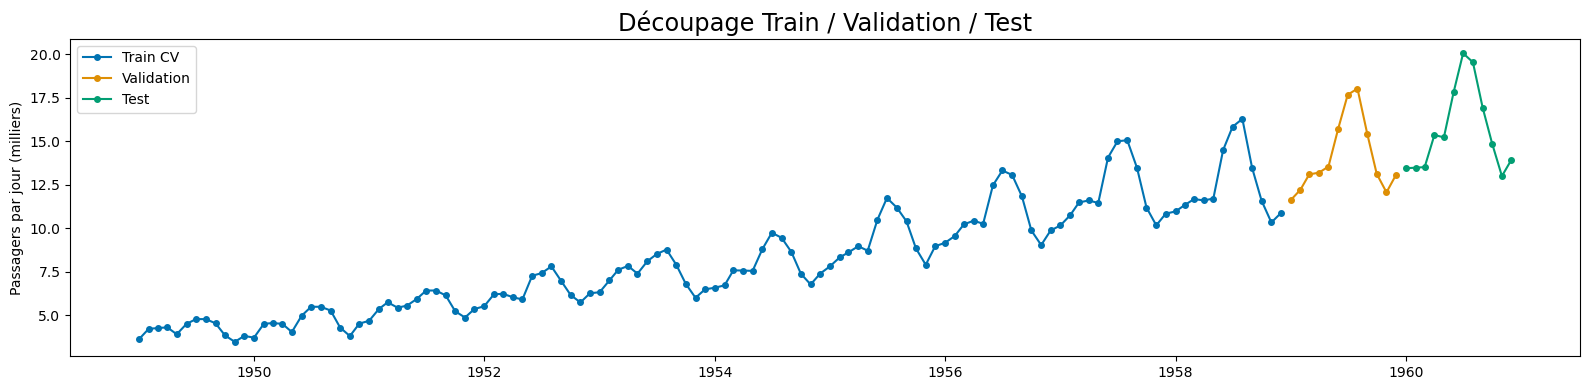

In [39]:
# ── Visualisation des 3 splits 
fig, ax = plot_series(
    train_cv, val_cv, test_sk,
    labels=['Train CV', 'Validation', 'Test'],
    title='Découpage Train / Validation / Test'
)
ax.set_ylabel('Passagers par jour (milliers)')
plt.tight_layout()
plt.show()

### 4.1 Cross-Validation with Naive model

**TODO**
- Perform a cross-validation with the Seasonal Naive model you built previously

In [40]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

HORIZON = 12  # We plan to make forecasts for the following 12 months
PERIOD = 12  # Expected period of seasonality

# Define the length of time into the future for which forecasts are to be prepared
fh = ForecastingHorizon(test.index, is_relative=False)

In [41]:
# Define the model
naive_cv          = NaiveForecaster(strategy='last')
seasonal_naive_cv = NaiveForecaster(strategy='last', sp=PERIOD)

# Call time_series_cv
print("\n=== CV — Naive Forecaster ===")
cv_results_naive = time_series_cv(
    forecaster=naive_cv,
    y=train_sk,
    train=train_cv,
    val=val_cv
)


# Show results
print("\n=== Résultats CV Naive ===")
print(cv_results_naive)
print("\n=== Résultats CV Seasonal Naive ===")
print(cv_results_seasonal)


=== CV — Naive Forecaster ===


TypeError: time_series_cv() got an unexpected keyword argument 'forecaster'

### 4.2 Cross-Validation with ARIMA

**TODO**
- Perform a cross-validation with your best ARIMA model. 
- Try different step values in the RollingForecastCV. What's the difference ?
- In each case, what's the size of the the data the model is trained on ?
- How many splits did we get ?

In [42]:
from pmdarima.arima import ARIMA
from pmdarima.model_selection import RollingForecastCV, cross_val_score

# Manually create the arima model
# pmdarima travaille sur des arrays numpy — on repasse sur le log
train_log_np = np.log(train_sk.values.astype(float))

# Modèle SARIMA (meilleur modèle identifié précédemment)
sarima_cv = ARIMA(order=(0, 1, 1),
                  seasonal_order=(0, 1, 1, 12))

# Create a RollingForecastCV instance
cv_strategy = RollingForecastCV(
    h=HORIZON,
    step=HORIZON,
    initial=len(train_log_np) - HORIZON * 2
)

# Call cross_val_score
cv_scores_sarima = cross_val_score(
    sarima_cv,
    train_log_np,
    cv=cv_strategy,
    scoring='mean_absolute_error',
    verbose=2
)

print("\n=== CV scores SARIMA (MAE sur log-scale) ===")
print(f"Scores par fold : {cv_scores_sarima.round(4)}")
print(f"Moyenne         : {cv_scores_sarima.mean():.4f}")
print(f"Std             : {cv_scores_sarima.std():.4f}")


[CV] fold=0 ..........................................................
[CV] fold=1 ..........................................................

=== CV scores SARIMA (MAE sur log-scale) ===
Scores par fold : [0.0726 0.0806]
Moyenne         : 0.0766
Std             : 0.0040


# 5. The Final Forecast

**TODO**
- Following the same methodology as above, produce your final forecast with your best model!
- Plot the predictions of the **Naive**, **Seasonal Naive**, and your best **SARIMA** model along with the test data, and compare they performances!

/home/youssef.hirchaou@Digital-Grenoble.local/anaconda3/envs/timeseries/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/youssef.hirchaou@Digital-Grenoble.local/anaconda3/envs/timeseries/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


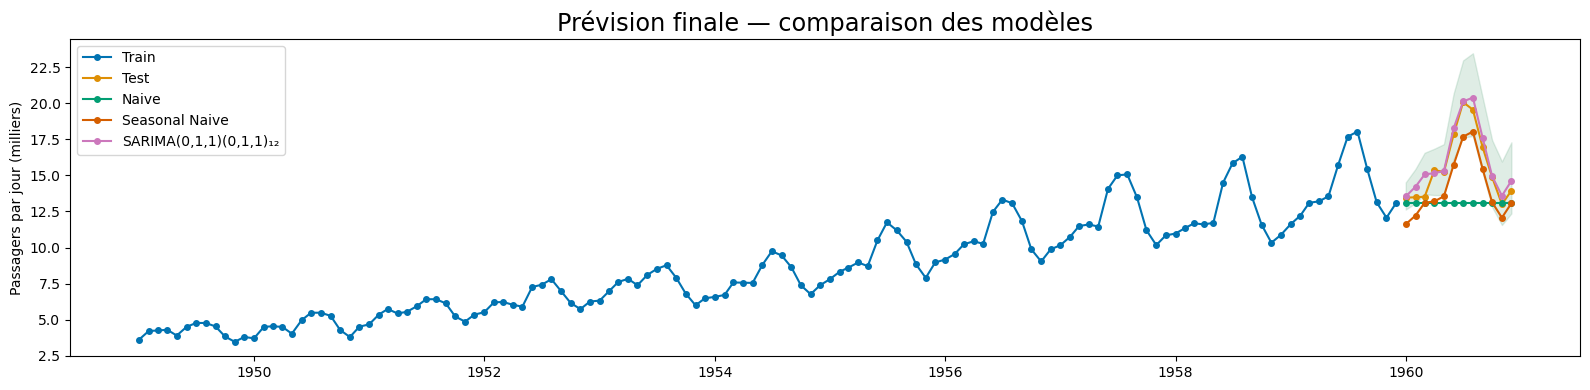

In [43]:
# Your code here
from sktime.utils.plotting import plot_series
from sktime.datasets import load_airline
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon

from pmdarima.utils import acf, pacf
from pmdarima import ARIMA

airline = load_airline().dropna()
airline = airline / airline.index.days_in_month
train, test = ts_train_test_split(airline, '1960-01-01')
train_log = np.log(train).dropna()

HORIZON = 12  # We plan to make forecasts for the following 12 months
PERIOD = 12  # Expected period of seasonality

train_log_full = np.log(train_sk.values.astype(float))
fh_final       = ForecastingHorizon(test_sk.index, is_relative=False)
# Define models
naive_final          = NaiveForecaster(strategy='last')
seasonal_naive_final = NaiveForecaster(strategy='last', sp=PERIOD)
sarima_final         = ARIMA(order=(0, 1, 1),
                              seasonal_order=(0, 1, 1, 12))

# Fit models

naive_final.fit(train_sk)
seasonal_naive_final.fit(train_sk)
sarima_final.fit(train_log_full)

# Create predictions
pred_naive_f    = naive_final.predict(fh_final)
pred_seasonal_f = seasonal_naive_final.predict(fh_final)

pred_sarima_log, conf_sarima_log = sarima_final.predict(
    n_periods=len(test_sk), return_conf_int=True
)
pred_sarima_f    = np.exp(pred_sarima_log)
conf_sarima_f    = np.exp(conf_sarima_log)

# Plot predictions
# Convertir pred_sarima en pd.Series avec le bon index pour plot_series
pred_sarima_series = pd.Series(
    pred_sarima_f,
    index=test_sk.index
)
#  Graphique comparatif — plot_series pour les modèles sktime
fig, ax = plot_series(
    train_sk, test_sk,
    pred_naive_f, pred_seasonal_f, pred_sarima_series,
    labels=['Train', 'Test',
            'Naive', 'Seasonal Naive', 'SARIMA(0,1,1)(0,1,1)₁₂'],
    title='Prévision finale — comparaison des modèles'
)
ax.fill_between(
    test_sk.index.to_timestamp(),
    conf_sarima_f[:, 0], conf_sarima_f[:, 1],
    color='seagreen', alpha=0.15, label='IC 95% SARIMA'
)
ax.set_ylabel('Passagers par jour (milliers)')
plt.tight_layout()
plt.show()

# Bonus

### B1. Write a class with the following methods:
* The necessary arguments to split the dataset, fit the auto_arima model etc.
* A `fit` method which fits the auto_arima naive using a train dataset
* A `get_metrics` method which computes the MAPE for each models using a test dataset
* A `predict` method which takes as input a prediction horizon and returns predicted values.
* A `plot` method which plots the data, and if available the predictions 

**Have some time left ?** 
* Add a method `get_cv` Which performs cross validation
* To further automatize the process, add an automatic detection of the period.
* Add the possibility to apply a preprocessing of the data before the fit such as a log transformation.

In [50]:
# Write your class here




### B2. Test this method on all the other [11 datasets] of pmdarima

https://alkaline-ml.com/pmdarima/modules/classes.html#module-pmdarima.datasets
To help you, we provide the list of dataset names and a function to load any of these datasets.

On some of them the method does not work well, why? What could be done to improve it?

In [19]:
dataset_names = ['airpassengers', 'ausbeer', 'austres', 'gasoline', 'heartrate', 'lynx', 'msft', 'sunspots', 'taylor', 'wineind', 'woolyrnq']

def get_ds(ds_name, red_factor=None):
    '''
    Loads a dataset of pmdarima from its ds_name.
    '''
    ds = getattr(pm.datasets, 'load_'+ds_name)(as_series=True).dropna()
    
    if red_factor is not None:
        assert isinstance(red_factor, int)
        ds= ds.groupby(np.arange(ds.index.shape[0])//red_factor).mean()
    
    return ds.dropna()

### B3. Want some more ?

Choose your poison: https://data.world/datasets/time-series